# Learning factors for stock market returns prediction
**proposed by QRT (Qube Research & Technologies): https://challengedata.ens.fr/challenges/72**
---

## Problem
Given a stock market of $N=50$ stocks having returns $R_t \in \mathbb{R}^N$ at time $t$, the goal is to design at each time $t$ a prediction vector $S_{t+1} \in \mathbb{R}^N$ from the information available up to time $t$ such that the prediction overlap, the value of the inner product $\langle S_{t+1}, R_{t+1} \rangle$ is often positive. More precisely, the value $\langle S_{t+1}, R_{t+1} \rangle>0$ indicates that two vectors (i,e., predictions), $S_{t+1}$ and $R_{t+1}$, are generally aligned, pointing in similar directions with an angle of less than $90$ degrees. It signifies a positive correlation or "overlap" between them. 

We attack this problem armed with a linear factor model where one learns the factors over an **exotic non-linear** parameter space.

---

## The Model
The simplest estimators being linear ones, a typical move is to consider a parametric model of the form:

$$S_{t+1} := \sum_{\ell=1}^{F} \beta_\ell F_{t,\ell}$$

**Where:**
* $F_{t,\ell} \in \mathbb{R}^N$ are explicative factors (features).
* $\beta_1, \dots, \beta_F \in \mathbb{R}$ are model parameters fitted on a training data set.

### Designing the Factors
The explicative factors $F_{t,\ell}$ are learned within the simplest class of factors—linear functions of the past returns:

$$F_{t,\ell} := \sum_{k=1}^{D} A_{k\ell} R_{t+1-k}$$

For some vectors $A_\ell := (A_{k\ell}) \in \mathbb{R}^D$ and a fixed time depth parameter $D$. To avoid redundancy, the vectors $A_\ell$ must be **orthonormal**: $\langle A_k, A_\ell \rangle = \delta_{kl}$.

---

## Challenge Goals
Participants must use a three-year history of 50 stocks (training set) to provide the model parameters $(A, \beta)$. The model is then tested against 50 different stocks over the same time period (testing set).

* **Number of stocks ($N$):** 50 
* **Time depth ($D$):** 250 days
* **Number of factors ($F$):** 10


### Output Structure
The expected output is a vector where the parameters $A \in \mathbb{R}^{250 \times 10}$ and $\beta \in \mathbb{R}^{10}$ are stacked:

$$\text{Output} = \begin{bmatrix} A_1 \\ \vdots \\ A_{10} \\ \beta \end{bmatrix} \in \mathbb{R}^{2510}$$

---

## Data Description
* **$X_{train}$:** A dataframe containing daily returns of 50 stocks over 754 days. Each row is a stock; each column is a day.
* **$Y_{train}$:** Provided for convenience, containing the returns to be predicted (already included in $X_{train}$).

---

## Benchmark Description (QRT Strategy)
A "brute force" procedure is provided as a benchmark:

1. **Repeat $N_{iter} = 1000$ times:**
    * Sample a $250 \times 10$ matrix $M$ with iid Gaussian $N(0,1)$ entries.
    * Apply **Gram-Schmidt** to obtain orthonormal columns ($A$).
    * Fit $\beta$ with minimal mean square error on the training set.
2. **Return** the parameters $(A, \beta)$ that maximize the training metric.


In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt


X_train = pd.read_csv('X_train.csv', index_col=0, sep=',')
X_train.columns.name = 'date'

Y_train = pd.read_csv('Y_train.csv', index_col=0, sep=',')
Y_train.columns.name = 'date'

In [2]:
X_train.shape, Y_train.shape

((50, 754), (50, 504))

In [3]:
x_np1 = X_train.to_numpy().T
x_np = np.stack([np.flip(x_np1[i:i+250], axis=0).T for i in range(len(x_np1)-250)])
y_np = Y_train.to_numpy().T

x_torch = torch.tensor(x_np)
y_torch = torch.tensor(y_np)

In [41]:
x_torch.shape, y_torch.shape

(torch.Size([504, 50, 250]), torch.Size([504, 50]))

In [44]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv('X_train.csv')
dg = pd.read_csv('Y_train.csv')

# 1. Handle stocksID (set as index if it exists, so it's not a feature)
if 'stocksID' in df.columns:
    df = df.set_index('stocksID')
if 'stocksID' in dg.columns:
    dg = dg.set_index('stocksID')    

# 2. Transpose: We want 754 Rows (Days) and 50 Columns (Stocks)
df_transposed = df.T
dg_transposed = dg.T

# 3. Scaling: Crucial! Without this, the most volatile stock 
# will dominate all 20 components.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_transposed)
Y_scaled = scaler.transform(dg_transposed)

# 4. Run PCA
pca = PCA(n_components=20)
X_pca = pca.fit_transform(X_scaled)
Y_pca = pca.transform(Y_scaled)

print("Cumulative Explained Variance (Corrected):")
print(pca.explained_variance_ratio_.cumsum())

# Why did cumulative explained variance changed?

Cumulative Explained Variance (Corrected):
[0.18981256 0.29282926 0.34312705 0.38280928 0.42104284 0.4535814
 0.480728   0.50609713 0.53090215 0.55458968 0.57730966 0.59927186
 0.61996616 0.63976458 0.65861301 0.67688432 0.69464958 0.71153716
 0.72790607 0.74291897]


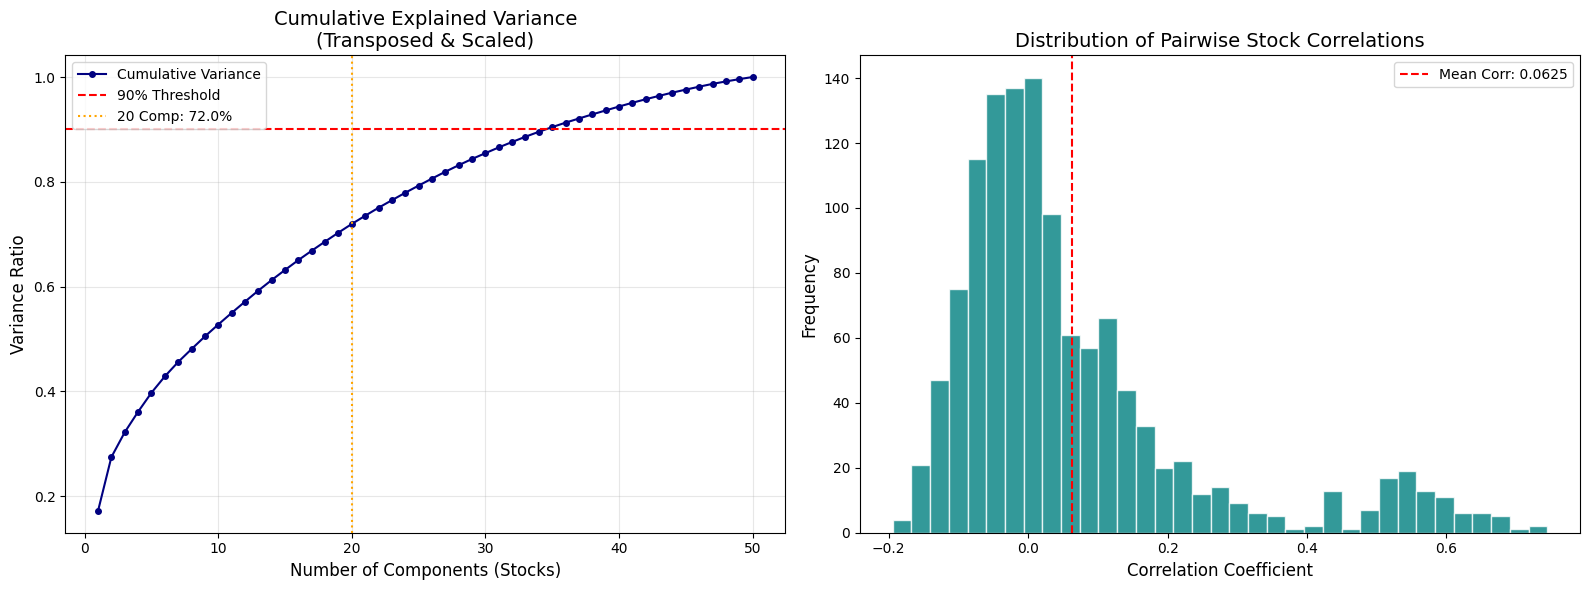

Variance explained by 20 components: 0.7197
Average correlation between stocks: 0.0625


In [45]:
# 1. Load your dataset
df = pd.read_csv('X_train.csv')

# 2. Correct Orientation: Transpose so Stocks are Features and Days are Samples
# We drop 'stocksID' first
X_transposed = df.drop(columns=['stocksID']).T 

# 3. Standardize the data (Mean=0, Variance=1)
# This is essential for stock returns to avoid high-volatility bias
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_transposed)

# 4. Initialize Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- PLOT 1: Cumulative Explained Variance ---
pca = PCA()
pca.fit(X_scaled)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

ax1.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 
         marker='o', markersize=4, color='navy', label='Cumulative Variance')
ax1.axhline(y=0.90, color='red', linestyle='--', label='90% Threshold')
ax1.axvline(x=20, color='orange', linestyle=':', label=f'20 Comp: {cumulative_variance[19]:.1%}')

ax1.set_title('Cumulative Explained Variance\n(Transposed & Scaled)', fontsize=14)
ax1.set_xlabel('Number of Components (Stocks)', fontsize=12)
ax1.set_ylabel('Variance Ratio', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend()

# --- PLOT 2: Correlation Histogram ---
# Calculate correlation matrix between the 50 stocks
corr_matrix = X_transposed.corr()

# Extract only the unique pairwise correlations (upper triangle)
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
correlations = corr_matrix.values[mask]

ax2.hist(correlations, bins=35, color='teal', edgecolor='white', alpha=0.8)
ax2.axvline(x=np.mean(correlations), color='red', linestyle='--', 
            label=f'Mean Corr: {np.mean(correlations):.4f}')

ax2.set_title('Distribution of Pairwise Stock Correlations', fontsize=14)
ax2.set_xlabel('Correlation Coefficient', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.legend()

plt.tight_layout()
plt.savefig('pca_full_analysis.png', dpi=300)
plt.show()

print(f"Variance explained by 20 components: {cumulative_variance[19]:.4f}")
print(f"Average correlation between stocks: {np.mean(correlations):.4f}")

In [47]:
X_pca.shape
x_np_pca = np.stack([np.flip(X_pca[i:i+250], axis=0).T for i in range(len(X_pca)-250)])

x_torch_pca = torch.tensor(x_np_pca)
y_torch_pca = torch.tensor(Y_pca)
x_torch_pca.shape, y_torch_pca.shape

(torch.Size([504, 20, 250]), torch.Size([504, 20]))


A **$F$-frame** is simply a collection of $F$ such vectors in an $n$-dimensional space. In your challenge, $D=250$ (a very "roomy" space) and $F=10$. You are trying to find 10 "directions" (factors) that are all perfectly perpendicular to one another. We use the concept of frame and the Stiefel Manifold to perform PCA-like learning.

---

### The Stiefel Manifold
The Stiefel manifold, denoted as $V_F(\mathbb{R}^D)$, is formally defined as the set of all $D \times F$ matrices $A$ such that:

$$V_F(\mathbb{R}^D) = \{ A \in \mathbb{R}^{D \times F} : A^T A = I_F \}$$

Where:
* $A$ is your matrix of factors.
* $I_F$ is the **Identity Matrix**.



### Why is this "Non-Linear"?
In a normal (linear) programming problem, if you have two valid solutions, any point between them is also a valid solution. 

This is **not true** here. If you take two matrices that are orthonormal and average them, the result is usually *not* orthonormal anymore (the vectors might shrink or lose their 90-degree angles). Because the "valid" space is a curved surface rather than a flat plane, we call it a **manifold**.

---

### Summary Table
| Term | Meaning in Plain English |
| :--- | :--- |
| **$D$ (250)** | The number of days of history you are looking at (the "length" of each vector). |
| **$F$ (10)** | The number of different "trends" or factors you are trying to extract. |
| **Orthonormal** | Each trend is unique (90° apart) and standardized (length of 1). |
| **Stiefel Manifold** | The "collection" of every possible way to pick 10 unique, standardized trends. |

In [48]:
import torch
from torch import nn, Tensor

class NNmodel(nn.Module):
    def __init__(self, D=250, F=10) -> None:
        super().__init__()
        self.D = D
        self.F = F     
        
        # Define the weights for the skew-symmetric matrix, with size D*(D-1)/2
        self.weight = nn.Parameter(torch.randn((D*(D-1)//2), dtype=torch.float64))
        # Define the beta parameters for the linear combination in the forward pass
        self.beta_parameters = nn.Parameter(torch.randn((F), dtype=torch.float64))

    @property
    def generator(self) -> Tensor:

# Generate the skew-symmetric matrix based on the weights. The upper triangular part of the matrix is filled with weights and the matrix is made Skew-symmetric from preSkew_symmetric.

        preSkew_symmetric = torch.zeros((self.D, self.D), dtype=torch.float64)
        
        # Fill the upper triangular part with the weights
        upper_triangle_indices = torch.triu_indices(self.D, self.D, offset=1)
        preSkew_symmetric[upper_triangle_indices[0], upper_triangle_indices[1]] = self.weight
        
        # Make the matrix skew-symmetric
        Skew_symmetric = preSkew_symmetric - preSkew_symmetric.T
        return Skew_symmetric
    
    @property     
    def A(self) -> Tensor:
        # Return the exponential of the generator fitted to the size (D, F).
        return torch.matrix_exp(self.generator)[:,:self.F]
    def learning_factors(self, x: Tensor) -> Tensor:
        # In this case, we will assume the factors are a simple linear transformation.
        return torch.matmul(x, self.A)  # (batch_size, D) x (D, F) -> (batch_size, F)
    
# output through forward-pairing required to run the nn.module neural network
    def forward(self, x: Tensor) -> Tensor:
        # The linear combination of the factors with the beta parameters.
        return torch.matmul(self.learning_factors(x), self.beta_parameters)  # (batch_size, F) x (F) -> (batch_size)



### Metric
The quality of the model is assessed by maximizing:

$$\text{Metric}(A, \beta) := \frac{1}{504} \sum_{t=250}^{753} \frac{\langle \tilde{S}_t, \tilde{R}_t \rangle}{\|\tilde{S}_t\| \|\tilde{R}_t\|}=\frac{1}{504}\sum_{t=250}^{753}\cos(\tilde{S}_t, \tilde{R}_t)$$

> **Note:** If the orthonormality condition $|\langle A_i, A_j \rangle - \delta_{ij}| \leq 10^{-6}$ is broken, the metric defaults to **-1**.


In [49]:
def metric_comparison(y1: Tensor, y2: Tensor) -> Tensor:
    # Normalize both tensors
    y1 = y1.div(y1.norm(keepdim=True, dim=1))
    y2 = y2.div(y2.norm(keepdim=True, dim=1))
    
    # Compute cosine similarity using the sum of element-wise products
    cosine_similarities = torch.sum(y1 * y2, dim=1)  # Element-wise product and sum along feature dimension
    return cosine_similarities.mean()

In [51]:
import torch

import time
start_time = time.time()

# Ensure random seed is set (assuming torch.seed is supposed to be set via torch.manual_seed)
torch.manual_seed(42)  # Set the random seed for reproducibility (or change the seed as needed)

# Initialize tracking variables for the best model and metrics
maxMetric = {'model1': -1}
updated_model = {'model1': None}
Metric_storage = {'model1': {'metric': []}}

n = 2000
output_dim = 1
model = NNmodel()

# from lion_pytorch import Lion
#optimizer = Lion(model.parameters(), lr=1e-4, weight_decay=1e-2)

#optimizer = torch.optim.Adam(model.parameters())

# Using AdamW optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, betas=(0.9, 0.999), eps=1e-08, weight_decay=1e-2)

model.train()

for t in range(n):
    optimizer.zero_grad()

    # Calculate the evaluation metric
    eval = metric_comparison(model(x_torch_pca), y_torch_pca)
    loss = -eval
    loss.backward()
    optimizer.step()

    # Convert evaluation value to a scalar and append it to the storage
    eval_value = eval.item()
    Metric_storage['model1']['metric'].append(eval_value)

    # Update the model if the evaluation is better than the current best metric
    if eval_value > maxMetric['model1']:
        maxMetric['model1'] = eval_value
        updated_model['model1'] = model
        updated_model['model1'].train(False)  # Switch to evaluation mode

    # Print progress every 300 iterations
    if t % 300 == 0:
        print(f"After {t:3d} iterations, we have improved the metric to {eval_value:1.7f}")



print("--- %s seconds ---" % (time.time() - start_time))




After   0 iterations, we have improved the metric to 0.0225418
After 300 iterations, we have improved the metric to 0.2002181
After 600 iterations, we have improved the metric to 0.2002181
After 900 iterations, we have improved the metric to 0.2002181
After 1200 iterations, we have improved the metric to 0.2002181
After 1500 iterations, we have improved the metric to 0.2002181
After 1800 iterations, we have improved the metric to 0.2002181
--- 25.176642179489136 seconds ---


In [9]:
A_flat1 = updated_model['model1'].A.reshape(2500)

print(A_flat1.shape) 

output1=torch.cat((A_flat1, updated_model['model1'].beta_parameters), dim=0)
print(output1.shape)
print(output1)
output1=torch.tensor(output1)
output_Kim1 = pd.DataFrame(output1)#convert to a dataframe

# To generate the final output of size [2510] from model 1
output_Kim1.to_csv("Output_Kim1.csv",index=True) #save to file

torch.Size([2500])
torch.Size([2510])
tensor([ 0.0861,  0.0022,  0.0036,  ...,  0.0483, -0.4127,  1.6737],
       dtype=torch.float64, grad_fn=<CatBackward0>)


/var/folders/tt/944h4xl91ll9w1sjmrxxzcmr0000gq/T/ipykernel_20373/1414586899.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  output1=torch.tensor(output1)


In [10]:
import torch

# Ensure random seed is set (assuming `torch.seed` is supposed to be set via `torch.manual_seed`)
torch.manual_seed(42)  # Set the random seed for reproducibility (or change the seed as needed)

n = 1000
output_dim = 1
model = NNmodel()

# from lion_pytorch import Lion
#optimizer = Lion(model.parameters(), lr=1e-4, weight_decay=1e-2)

#optimizer = torch.optim.Adam(model.parameters())

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, betas=(0.9, 0.999), eps=1e-08, weight_decay=1e-2)

# Initialize storage for metrics
maxMetric = {'model2': -1}
updated_model = {'model2': None}
Metric_storage = {'model2': {'metric': []}}

model.train()

for t in range(n):
    optimizer.zero_grad()
    
    # Undo robust scaling using in-place operations to minimize memory usage
    updated_x = ((model(x_robust_torch)) * IQR_to_size_ynp_rescale) + Median_to_size_ynp_rescale
    
    # Compute metric and loss
    eval = metric_comparison(updated_x, y_torch)
    loss = -eval
    loss.backward()
    optimizer.step()
    
    # Convert the evaluation to a scalar
    eval_value = eval.item()
    Metric_storage['model2']['metric'].append(eval_value)
    
    # Update the model if we find an improvement
    if eval_value > maxMetric['model2']:
        maxMetric['model2'] = eval_value
        updated_model['model2'] = model
        updated_model['model2'].train(False)  # Switch to evaluation mode
    
    # Print progress every 300 iterations
    if t % 300 == 0:
        print(f"After {t:3d} iterations, we have improved the metric to {eval_value:1.7f}")


NameError: name 'x_robust_torch' is not defined

In [ ]:
A_flat2 = updated_model['model2'].A.reshape(2500)

print(A_flat2.shape) 

output2=torch.cat((A_flat2, updated_model['model2'].beta_parameters), dim=0)
print(output2.shape)
print(output2)
output2=torch.tensor(output2)
output_Kim2 = pd.DataFrame(output2)#convert to a dataframe

# To generate the final output of size [2510] from model 2
output_Kim2.to_csv("Output_Kim2.csv",index=True) #save to file

In [ ]:
import torch

# Ensure random seed is set (assuming torch.seed is supposed to be set via torch.manual_seed)
torch.manual_seed(42)  # Set the random seed for reproducibility (or change the seed as needed)

# Initialize tracking variables for the best model and metrics
maxMetric = {'model3': -1}
updated_model = {'model3': None}
Metric_storage = {'model3': {'metric': []}}

n = 1000
output_dim = 1
model = NNmodel()


# from lion_pytorch import Lion
#optimizer = Lion(model.parameters(), lr=1e-4, weight_decay=1e-2)

#optimizer = torch.optim.Adam(model.parameters())

# Using AdamW optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, betas=(0.9, 0.999), eps=1e-08, weight_decay=1e-2)

# Set the model to training mode
model.train()

for t in range(n):
    optimizer.zero_grad()

    # Undo robust scaling using in-place operations to minimize memory usage
    updated_x = ((model(x_robust_rescaled)) * IQR_to_size_ynp_rescale) + Median_to_size_ynp_rescale
    
    # Calculate the evaluation metric
    eval = metric_comparison(updated_x, y_torch)
    loss = -eval
    loss.backward()
    optimizer.step()

    # Convert evaluation value to a scalar and append it to the storage
    eval_value = eval.item()
    Metric_storage['model3']['metric'].append(eval_value)

    # Update the model if the evaluation is better than the current best metric
    if eval_value > maxMetric['model3']:
        maxMetric['model3'] = eval_value
        updated_model['model3'] = model
        updated_model['model3'].train(False)  # Switch to evaluation mode

    # Print progress every 300 iterations
    if t % 300 == 0:
        print(f"After {t:3d} iterations, we have improved the metric to {eval_value:1.7f}")


In [ ]:
A_flat3 = updated_model['model3'].A.reshape(2500)

print(A_flat3.shape) 

output3=torch.cat((A_flat3, updated_model['model3'].beta_parameters), dim=0)
print(output3.shape)
print(output3)
output3=torch.tensor(output3)
output_Kim3 = pd.DataFrame(output3)#convert to a dataframe

# To generate the final output of size [2510] from model 3
output_Kim3.to_csv("Output_Kim3.csv",index=True) #save to file

In [17]:
print(updated_model['model3'].A)

tensor([[ 0.0863,  0.0133,  0.0730,  ...,  0.0375, -0.1141, -0.0249],
        [-0.0694,  0.0492, -0.0421,  ..., -0.0068,  0.0092,  0.0193],
        [ 0.0487,  0.0550, -0.0876,  ...,  0.0503, -0.0668, -0.0843],
        ...,
        [ 0.1392,  0.0723, -0.0674,  ..., -0.1020,  0.1198,  0.1169],
        [ 0.0076, -0.0702, -0.0711,  ..., -0.0333,  0.0721,  0.0324],
        [ 0.0544, -0.0502,  0.0091,  ...,  0.1095,  0.0490, -0.1682]],
       dtype=torch.float64, grad_fn=<SliceBackward0>)


In [18]:
print(updated_model['model3'].A.shape)

torch.Size([250, 10])


In [19]:
print(updated_model['model3'].beta_parameters)

Parameter containing:
tensor([-0.0052, -0.0073,  0.0064,  0.0229,  0.1772,  0.0084,  0.0026, -0.0002,
        -0.0091,  0.1578], dtype=torch.float64, requires_grad=True)


In [20]:
print(updated_model['model3'].beta_parameters.shape)

torch.Size([10])


In [21]:
#Somehow the data removing outliers outside of IQR does not help improving the learning process.
#Robust scaling with outliers gives better predictions.

import torch

# Ensure random seed is set (assuming `torch.seed` is supposed to be set via `torch.manual_seed`)
torch.manual_seed(42)  # Set the random seed for reproducibility (or change the seed as needed)

n = 1000
output_dim = 1
model = NNmodel()

# from lion_pytorch import Lion
#optimizer = Lion(model.parameters(), lr=1e-4, weight_decay=1e-2)

#optimizer = torch.optim.Adam(model.parameters())

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, betas=(0.9, 0.999), eps=1e-08, weight_decay=1e-2)

# Initialize storage for metrics
maxMetric = {'model4': -1}
updated_model = {'model4': None}
Metric_storage = {'model4': {'metric': []}}

model.train()

for t in range(n):
    optimizer.zero_grad()
    
    # Undo robust scaling using in-place operations to minimize memory usage
    updated_x = ((model(x_robust_torch_cleaned)) * IQR_to_size_ynp_rescale_cleaned) + Median_to_size_ynp_rescale_cleaned
    # Compute metric and loss
    eval = metric_comparison(updated_x, y_torch)
    loss = -eval
    loss.backward()
    optimizer.step()
    
    # Convert the evaluation to a scalar
    eval_value = eval.item()
    Metric_storage['model4']['metric'].append(eval_value)
    
    # Update the model if we find an improvement
    if eval_value > maxMetric['model4']:
        maxMetric['model4'] = eval_value
        updated_model['model4'] = model
        updated_model['model4'].train(False)  # Switch to evaluation mode
    
    # Print progress every 300 iterations
    if t % 300 == 0:
        print(f"After {t:3d} iterations, we have improved the metric to {eval_value:1.5f}")

After   0 iterations, we have improved the metric to 0.01231
After 300 iterations, we have improved the metric to 0.14754
After 600 iterations, we have improved the metric to 0.14757
After 900 iterations, we have improved the metric to 0.14761
After 1200 iterations, we have improved the metric to 0.14770
After 1500 iterations, we have improved the metric to 0.14793
After 1800 iterations, we have improved the metric to 0.14949
After 2100 iterations, we have improved the metric to 0.15017
After 2400 iterations, we have improved the metric to 0.15017
After 2700 iterations, we have improved the metric to 0.15017
After 3000 iterations, we have improved the metric to 0.15017
After 3300 iterations, we have improved the metric to 0.15017
After 3600 iterations, we have improved the metric to 0.15017
After 3900 iterations, we have improved the metric to 0.15017
After 4200 iterations, we have improved the metric to 0.15017
After 4500 iterations, we have improved the metric to 0.15017
After 4800 i

In [22]:
A4_flat = updated_model['model4'].A.reshape(2500)

print(A4_flat.shape) 

output4=torch.cat((A4_flat, updated_model['model4'].beta_parameters), dim=0)
print(output4.shape)
print(output4)
output4=torch.tensor(output4)
output_Kim4 = pd.DataFrame(output4)#convert to a dataframe

# To generate the final output of size [2510] from model 4
output_Kim4.to_csv("Output_Kim4.csv",index=True) #save to file

torch.Size([2500])
torch.Size([2510])
tensor([ 0.0933,  0.0224,  0.1311,  ..., -0.0026, -0.0094,  0.1461],
       dtype=torch.float64, grad_fn=<CatBackward0>)


/var/folders/tt/944h4xl91ll9w1sjmrxxzcmr0000gq/T/ipykernel_26016/2016537951.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  output4=torch.tensor(output4)
